# CLIPSeg-debris Inference on DesignSafe (PRJ-6029, CPU/GPU)

This notebook is only designed to be used in the **webinar** and to run in **DesignSafe Jupyter (standard JupyterHub)**.

It demonstrates how to:

1. Define a simple, reproducible **project structure** based on where this notebook is located.
2. Access the **published DesignSafe dataset** (PRJ-6029) directly from the mounted **NHERI-Published** filesystem.
3. Load the **CLIPSeg-debris research software snapshot** from DesignSafe (PRJ-6225, v1.0.1), or clone the GitHub repository as a fallback.
4. **Install** the Python dependencies in the current DesignSafe environment.
5. Load a **local model weight (.ckpt) file** that you upload manually.
6. Showcase a subset of images from the dataset (`original/`).
7. Run **CLIPSeg-debris** inference on those images using **GPU if available, otherwise CPU**.
8. Visualize side-by-side **input images vs. predicted debris masks**.

### Useful links
- **CLIPSeg-debris research software (DesignSafe PRJ-6225, v1.0.1):**  
  https://www.designsafe-ci.org/data/browser/public/designsafe.storage.published/PRJ-6225  
  DOI: `10.17603/ds2-yt43-hw55`
- **GitHub repository (CLIPSeg-debris, code mirror):**  
  https://github.com/Way-Yuhao/CLIPSeg-debris
- **DesignSafe published dataset (PRJ-6029 landing page):**  
  https://www.designsafe-ci.org/data/browser/public/designsafe.storage.published/PRJ-6029

## 1. Set Up Paths

In this step, we:

- Locate the **current notebook directory**.
- Define a **project root** as the parent folder of this notebook (so you can easily copy the whole folder).
- Specify where the repository, weights, experiments, and dataset are located.
- Point `DATASET_ROOT` to the **published PRJ-6029 dataset** mounted under `/home/jupyter/NHERI-Published` on DesignSafe Jupyter.

In [37]:
from pathlib import Path
import os

# ------------------------------------------------------------------
# Anchor NOTEBOOK_DIR the first time, and reuse it later
# ------------------------------------------------------------------
if "NOTEBOOK_DIR" not in globals():
    # On first run, assume CWD is the notebook directory
    NOTEBOOK_DIR = Path.cwd().resolve()
    print("Initialized NOTEBOOK_DIR:", NOTEBOOK_DIR)
else:
    print("Reusing NOTEBOOK_DIR:", NOTEBOOK_DIR)

# Project root is the parent directory of the notebook:
PROJECT_ROOT = NOTEBOOK_DIR.parent

# CLIPSeg-debris repo location (will be cloned here)
REPO_ROOT = PROJECT_ROOT / "CLIPSeg-debris"

# Weights folder (YOU create this and upload the weight file manually)
WEIGHTS_DIR = PROJECT_ROOT / "weights"

# Experiments folder for inputs/outputs created by this notebook
EXPERIMENTS_ROOT = PROJECT_ROOT / "experiments"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPO_ROOT:", REPO_ROOT)
print("WEIGHTS_DIR:", WEIGHTS_DIR)
print("EXPERIMENTS_ROOT:", EXPERIMENTS_ROOT)

# ------------------------------------------------------------------
# Published dataset root for PRJ-6029 on DesignSafe Jupyter
# ------------------------------------------------------------------

BASE_PUBLISHED = Path("/home/jupyter/NHERI-Published")

print("\nBASE_PUBLISHED:", BASE_PUBLISHED)
print("BASE_PUBLISHED exists? ->", BASE_PUBLISHED.exists())

DATASET_ROOT = BASE_PUBLISHED / "published-data" / "PRJ-6029" / \
    "Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2" / \
    "data"

print("\nDATASET_ROOT:", DATASET_ROOT)
print("DATASET_ROOT exists? ->", DATASET_ROOT.exists())

if DATASET_ROOT.exists():
    print("Subfolders under DATASET_ROOT:", [p.name for p in DATASET_ROOT.iterdir()])
else:
    print("\n⚠️ DATASET_ROOT does not exist.")
    print("   In the Jupyter file browser, right-click the 'data' folder for PRJ-6029,")
    print("   choose 'Copy Path', and paste that here to replace DATASET_ROOT.")

Reusing NOTEBOOK_DIR: /home/jupyter/Work/vista/clipseg_debris_demo/notebooks
PROJECT_ROOT: /home/jupyter/Work/vista/clipseg_debris_demo
REPO_ROOT: /home/jupyter/Work/vista/clipseg_debris_demo/CLIPSeg-debris
WEIGHTS_DIR: /home/jupyter/Work/vista/clipseg_debris_demo/weights
EXPERIMENTS_ROOT: /home/jupyter/Work/vista/clipseg_debris_demo/experiments

BASE_PUBLISHED: /home/jupyter/NHERI-Published
BASE_PUBLISHED exists? -> True

DATASET_ROOT: /home/jupyter/NHERI-Published/published-data/PRJ-6029/Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2/data
DATASET_ROOT exists? -> True
Subfolders under DATASET_ROOT: ['README.txt', 'prompts_vis', 'annotations', 'original', 'Paper Supplementary Material.pdf', 'annotations_vis']


## 2. Clone `CLIPSeg-debris`

This step:

- Changes the working directory to `PROJECT_ROOT`.
- Clones the **CLIPSeg-debris** repository into `CLIPSeg-debris/` if it does not already exist.

You typically only need to run this **once per environment** (unless you delete the repo or want to re-clone it).

In [38]:
import os
import subprocess
import zipfile
import shutil
from pathlib import Path

# Make sure we're at the project root
os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

# -------------------------------------------------------------------
# Option 1 (preferred): Use DesignSafe research software snapshot
#   PRJ-6225 | Debris Segmentation Model using Post-Hurricane Aerial Imagery (CLIPSeg-debris)
#   DOI: 10.17603/ds2-yt43-hw55
#
# ZIP path on DesignSafe Jupyter:
#   /home/jupyter/NHERI-Published/published-data/PRJ-6225/
#       Project--debris-segmentation-model-using-post-hurricane-aerial-imagery-clipseg-debris/
#           data/CLIPSeg-debris_v1.0.1.zip
# -------------------------------------------------------------------
software_zip_path = Path(
    "/home/jupyter/NHERI-Published/published-data/PRJ-6225/"
    "Project--debris-segmentation-model-using-post-hurricane-aerial-imagery-clipseg-debris/"
    "data/CLIPSeg-debris_v1.0.1.zip"
)

if REPO_ROOT.exists():
    print("✅ CLIPSeg-debris repository already exists at:", REPO_ROOT)
else:
    if software_zip_path.exists():
        print("📦 Found DesignSafe research software ZIP for CLIPSeg-debris v1.0.1:")
        print("   ", software_zip_path)

        tmp_extract_dir = PROJECT_ROOT / "_clipseg_extract_tmp"
        # Clean up any previous temp extraction
        if tmp_extract_dir.exists():
            shutil.rmtree(tmp_extract_dir)

        print("📂 Extracting ZIP to temporary folder:", tmp_extract_dir)
        tmp_extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(software_zip_path, "r") as zf:
            zf.extractall(tmp_extract_dir)

        # Automatically detect the top-level extracted folder (e.g., "Way-Yuhao-CLIPSeg-debris-64da464")
        top_level_dirs = [p for p in tmp_extract_dir.iterdir() if p.is_dir()]
        if not top_level_dirs:
            raise RuntimeError(
                f"No top-level directory found under {tmp_extract_dir}. "
                "Please inspect the ZIP contents."
            )
        if len(top_level_dirs) > 1:
            print("⚠️ Multiple top-level directories found in the ZIP. Using the first one:")
            for p in top_level_dirs:
                print("   -", p)
        extracted_root = top_level_dirs[0]
        print("📁 Detected extracted root:", extracted_root)

        print("📁 Moving extracted repository to:", REPO_ROOT)
        shutil.move(str(extracted_root), str(REPO_ROOT))

        # Remove the temporary extraction directory if it is now empty
        try:
            shutil.rmtree(tmp_extract_dir)
        except Exception:
            pass  # it's okay if this fails; it's just cleanup

        print("✅ Using CLIPSeg-debris from DesignSafe project PRJ-6225 at:", REPO_ROOT)

    else:
        # -------------------------------------------------------------------
        # Option 2: Fallback to cloning from GitHub (tag v1.0.1)
        # -------------------------------------------------------------------
        print("⚠️ DesignSafe research software ZIP not found at:")
        print("   ", software_zip_path)
        print("📥 Falling back to cloning from GitHub (v1.0.1 release):")
        print("   https://github.com/Way-Yuhao/CLIPSeg-debris/releases/tag/v1.0.1")

        subprocess.check_call([
            "git",
            "clone",
            "--branch", "v1.0.1",
            "--depth", "1",
            "https://github.com/Way-Yuhao/CLIPSeg-debris.git",
            str(REPO_ROOT),
        ])

        print("✅ Cloned CLIPSeg-debris v1.0.1 into:", REPO_ROOT)

Working directory: /home/jupyter/Work/vista/clipseg_debris_demo
✅ CLIPSeg-debris repository already exists at: /home/jupyter/Work/vista/clipseg_debris_demo/CLIPSeg-debris


## 3. Install Python Dependencies (once per environment)

This step installs the Python packages needed by **CLIPSeg-debris** into your **user space** (using `pip --user`).

- The cell prints a short line for each package.
- The `-q` (quiet) flag is used with `pip` to **suppress most of the verbose logs**, so the notebook output stays readable.

> If you ever need full installation logs (for debugging), you can remove the `-q` flag from the pip command.

In [39]:
import sys
import subprocess

print("📦 Installing Python dependencies into the current DesignSafe environment (user-level)...")

packages = [
    "hydra-core",
    "omegaconf==2.3.0",
    "hydra-colorlog>=1.2.0",
    "colorlog>=6.8,<7",
    "lightning==2.4.0",
    "lightning_utilities",
    "openai-clip",
    "general_utils==0.1.16",
    "rootutils==1.0.7",
    "natsort==8.4.0",
    "ipywidgets>=8",
    "gradio>=4",
    "opencv-python-headless", 
    "wandb",                   
    "torchvision",             
    "scikit-learn",   
]

for pkg in packages:
    print(f"  -> Installing {pkg} ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--user", "-q", pkg]
    )

print("\n✅ Dependency installation step finished. You should see one line per package above. For full logs, rerun without '-q'.")

📦 Installing Python dependencies into the current DesignSafe environment (user-level)...
  -> Installing hydra-core ...
  -> Installing omegaconf==2.3.0 ...
  -> Installing hydra-colorlog>=1.2.0 ...
  -> Installing colorlog>=6.8,<7 ...
  -> Installing lightning==2.4.0 ...
  -> Installing lightning_utilities ...
  -> Installing openai-clip ...
  -> Installing general_utils==0.1.16 ...
  -> Installing rootutils==1.0.7 ...
  -> Installing natsort==8.4.0 ...
  -> Installing ipywidgets>=8 ...
  -> Installing gradio>=4 ...
  -> Installing opencv-python-headless ...
  -> Installing wandb ...
  -> Installing torchvision ...
  -> Installing scikit-learn ...

✅ Dependency installation step finished. You should see one line per package above. For full logs, rerun without '-q'.


## 8. Verify Model Weights

This cell checks that the file exists and will be used for inference.

In [40]:
# Path to the checkpoint file (YOU must upload this file)
ckpt_path = WEIGHTS_DIR / "clipseg_debris_weight.ckpt"

print("Expected weight file path:", ckpt_path)
if not ckpt_path.exists():
    raise FileNotFoundError(
        f"Model weights not found at {ckpt_path}.\n"
        "Please create the 'weights/' folder under your project root and "
        "upload 'clipseg_debris_weight.ckpt' there before proceeding."
    )

print("✅ Using model weights at:", ckpt_path)

Expected weight file path: /home/jupyter/Work/vista/clipseg_debris_demo/weights/clipseg_debris_weight.ckpt
✅ Using model weights at: /home/jupyter/Work/vista/clipseg_debris_demo/weights/clipseg_debris_weight.ckpt


## 8. Import CLIPSeg-debris Code

This cell:

- Adds the repo root to `sys.path` so Python can find the `src` package.
- Imports the `evaluate` function used for inference.

In [41]:
import sys

# Ensure repo root (which contains src/) is on sys.path
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.eval import evaluate

print("✅ Imported CLIPSeg-debris modules.")

✅ Imported CLIPSeg-debris modules.


## 8. Prepare a Random Sample of Images from the Dataset

This cell:

- Defines an input directory under `experiments/demo/input_images/`.
- Ensures the experiments directory structure exists.
- Samples a subset (e.g., 10 images) from `original/` in PRJ-6029.
- Copies those images into the input directory for inference.

In [42]:
import random
import shutil
from pathlib import Path

# ---------------------------------------------------------
# Choose how to select images for the demo:
#   "showcase" -> use specific example IDs listed below (DEFAULT)
#   "random"   -> pick a random subset from all images
# ---------------------------------------------------------
SELECTION_MODE = "showcase"  # change to "random" if you want random sampling

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"DATASET_ROOT does not exist: {DATASET_ROOT}.\n"
        "Fix the path in the previous cell before continuing."
    )

# Images live in the 'original/' folder under DATASET_ROOT
IMAGES_ROOT = DATASET_ROOT / "original"
print("IMAGES_ROOT:", IMAGES_ROOT)
print("IMAGES_ROOT exists? ->", IMAGES_ROOT.exists())

if not IMAGES_ROOT.exists():
    raise FileNotFoundError(
        f"'original' folder not found at {IMAGES_ROOT}.\n"
        "Check the PRJ-6029 project structure and update IMAGES_ROOT if needed."
    )

# Create experiments folder and input directory
input_dir = EXPERIMENTS_ROOT / "demo" / "input_images"
input_dir.mkdir(parents=True, exist_ok=True)

print("Input directory for inference:", input_dir)

# Clear any previous contents in the input directory
for f in input_dir.glob("*"):
    if f.is_file():
        f.unlink()

# ---------------------------------------------------------
# Option A: Showcase images (default)
# ---------------------------------------------------------
showcase_ids = [
    "000363",
    "000325",
    "000357",
    "020440",
    "000226",
    "013127",
    "020243",
    "002476",
    "020487",
    "000029",
    "009807",
    "000032",
    "000024",
    "022280",
]

sampled_paths = []

if SELECTION_MODE.lower() == "showcase":
    print("\n🔎 Using predefined showcase examples (default).")
    for img_id in showcase_ids:
        # Files are named like: post-rgb-000363_merged_50m.png
        fname = f"post-rgb-{img_id}_merged_50m.png"
        path = IMAGES_ROOT / fname
        if path.exists():
            sampled_paths.append(path)
        else:
            print(f"  ⚠️ Showcase file not found, skipping: {path}")

    if not sampled_paths:
        raise RuntimeError(
            "None of the showcase images were found in the 'original/' folder.\n"
            "Check the IDs or switch SELECTION_MODE to 'random'."
        )

# ---------------------------------------------------------
# Option B: Random sampling
# ---------------------------------------------------------
else:
    print("\n🎲 Using random sampling mode.")
    # Find all images in original/
    all_images = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"):
        all_images.extend(IMAGES_ROOT.glob(ext))

    print(f"Found {len(all_images)} image file(s) under {IMAGES_ROOT}.")

    if not all_images:
        raise RuntimeError("No images found in the 'original/' folder.")

    # Number of random samples to use for inference
    num_samples = 10  # you can change this value if desired
    num_samples = min(num_samples, len(all_images))

    sampled_paths = random.sample(all_images, num_samples)

# ---------------------------------------------------------
# Copy selected images into the input directory
# ---------------------------------------------------------
for src_img in sampled_paths:
    shutil.copy(src_img, input_dir / src_img.name)

print(f"\n✅ Copied {len(sampled_paths)} image(s) into {input_dir} for inference.")
print("Selection mode:", SELECTION_MODE)

IMAGES_ROOT: /home/jupyter/NHERI-Published/published-data/PRJ-6029/Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2/data/original
IMAGES_ROOT exists? -> True
Input directory for inference: /home/jupyter/Work/vista/clipseg_debris_demo/experiments/demo/input_images

🔎 Using predefined showcase examples (default).

✅ Copied 14 image(s) into /home/jupyter/Work/vista/clipseg_debris_demo/experiments/demo/input_images for inference.
Selection mode: showcase


## 8. Run CLIPSeg-debris Inference (CPU/GPU)

This cell:

- Detects whether a CUDA GPU is available.
- If a GPU is available, sets `trainer.accelerator=gpu` and `trainer.devices=[0]`.
- Otherwise, forces **CPU** execution via `trainer.accelerator=cpu` and `trainer.devices=1`.
- Points Hydra to the configuration directory in the cloned repo.
- Builds a configuration object with overrides for:
  - Checkpoint path
  - Device settings
  - Input image directory
  - Output directory and experiment name
- Calls `evaluate(cfg)` to run inference.

In [43]:
from hydra import compose, initialize_config_dir
import pathlib
import torch

prediction_parent_dir = EXPERIMENTS_ROOT
prediction_dir = "demo"
cfg_dir = REPO_ROOT / "configs"

prediction_parent_dir = pathlib.Path(prediction_parent_dir)
cfg_dir = pathlib.Path(cfg_dir)
prediction_parent_dir.mkdir(parents=True, exist_ok=True)

if not list(pathlib.Path(input_dir).iterdir()):
    print("⚠️ Input directory is empty. Run the sampling cell first.")
else:
    use_gpu = torch.cuda.is_available()
    print(f"CUDA available? -> {use_gpu}")

    device_overrides = []
    if use_gpu:
        print("Using GPU (trainer.accelerator=gpu, trainer.devices=[0])")
        device_overrides.append("trainer.accelerator=gpu")
        device_overrides.append("trainer.devices=[0]")
    else:
        print("Using CPU (trainer.accelerator=cpu, trainer.devices=1)")
        device_overrides.append("trainer.accelerator=cpu")
        device_overrides.append("trainer.devices=1")

    print("Configuring model for evaluation...")

    with initialize_config_dir(
        version_base="1.2",
        config_dir=str(cfg_dir),
        job_name="demo",
    ):
        overrides = [
            f"ckpt_path={ckpt_path}",
            f"data.query_images_dir={input_dir}",
            f"+local.prediction_output_dir={prediction_parent_dir}",
            f"+local.data_dir={input_dir}",
            f"name={prediction_dir}",
        ] + device_overrides

        cfg = compose(
            config_name="eval",
            overrides=overrides,
        )

    print("Running inference...")
    evaluate(cfg)
    print("\n✅ Inference complete!")

CUDA available? -> False
Using CPU (trainer.accelerator=cpu, trainer.devices=1)
Configuring model for evaluation...
Running inference...


Seed set to 42
[rank: 0] No logger configs found! Skipping...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at /home/jupyter/Work/vista/clipseg_debris_demo/weights/clipseg_debris_weight.ckpt
Loaded model weights from the checkpoint at /home/jupyter/Work/vista/clipseg_debris_demo/weights/clipseg_debris_weight.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Inference complete!


## 8. Visualize Sample Predictions

This cell:

- Looks for the `original/` and `predictions/` folders created by CLIPSeg-debris under `experiments/demo/`.
- For each pair of input and prediction images, displays them side-by-side for inspection.

Input images dir: /home/jupyter/Work/vista/clipseg_debris_demo/experiments/demo/original
Prediction images dir: /home/jupyter/Work/vista/clipseg_debris_demo/experiments/demo/predictions


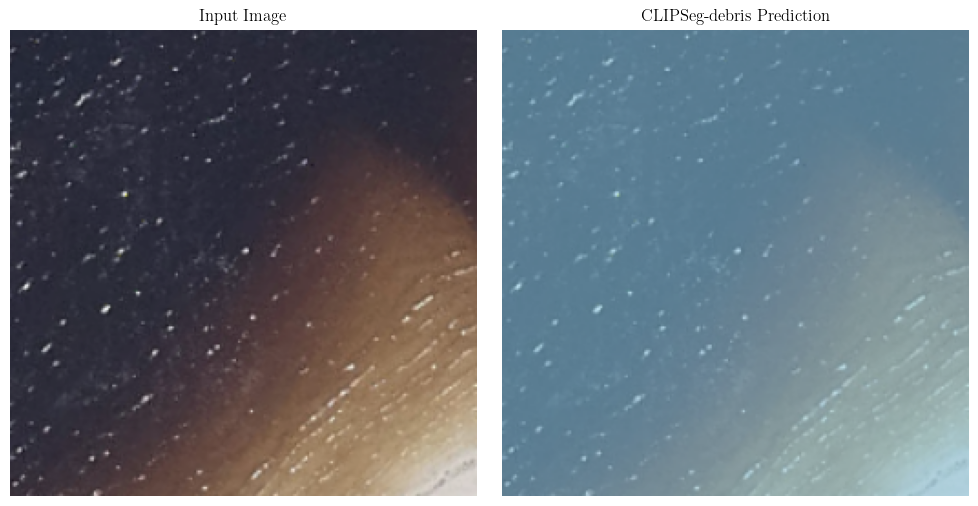

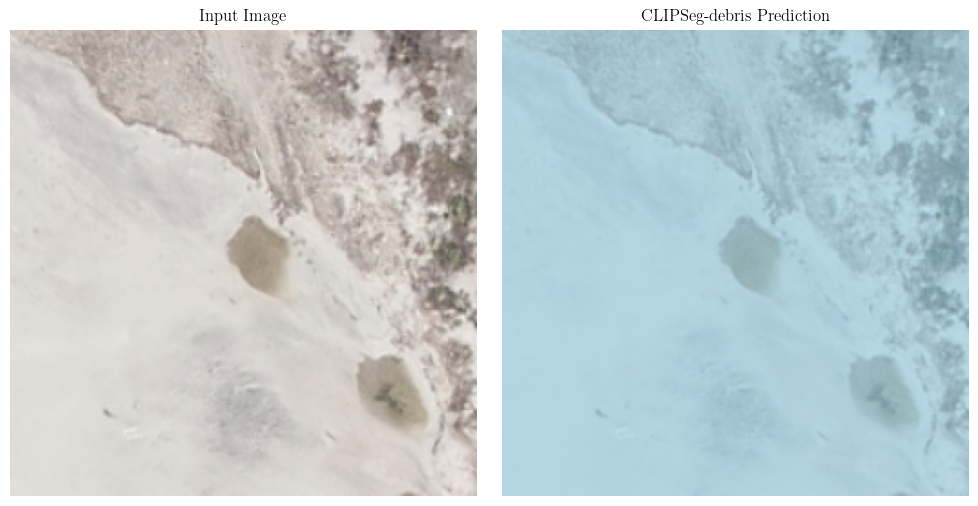

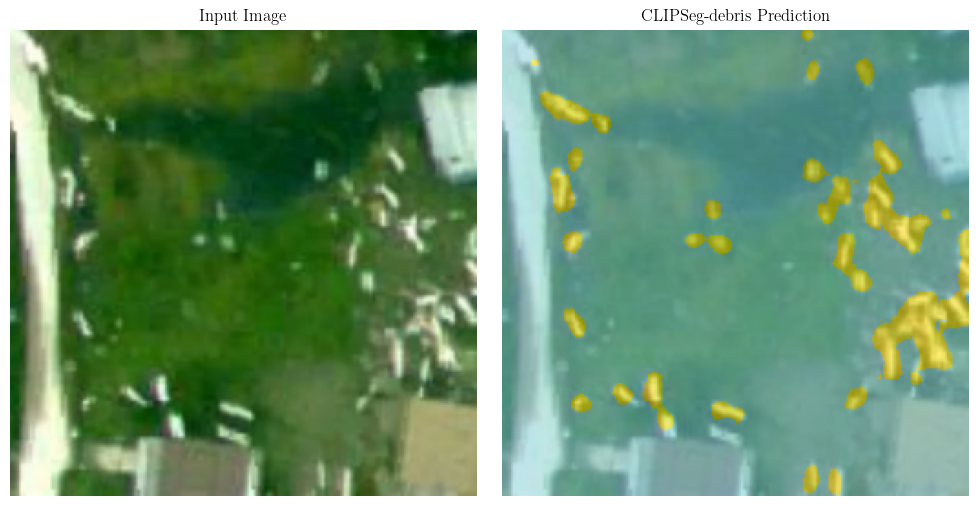

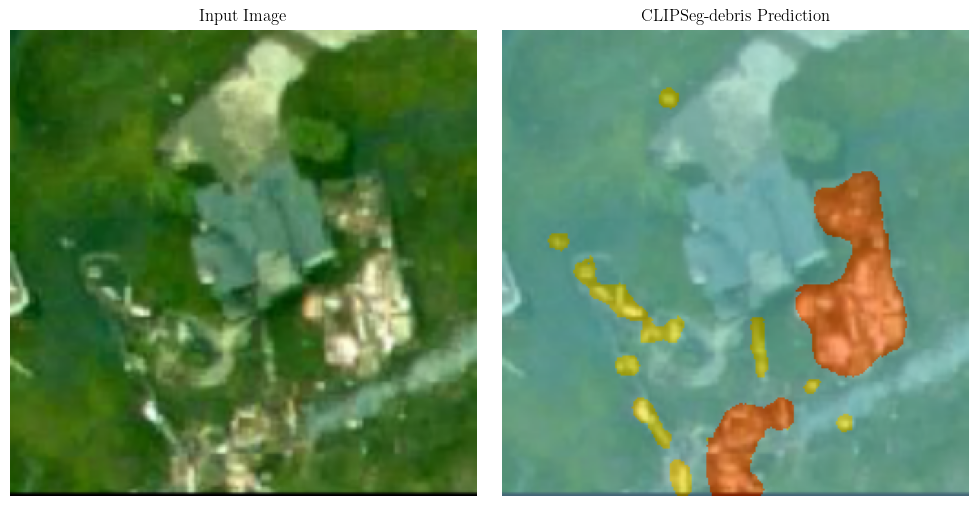

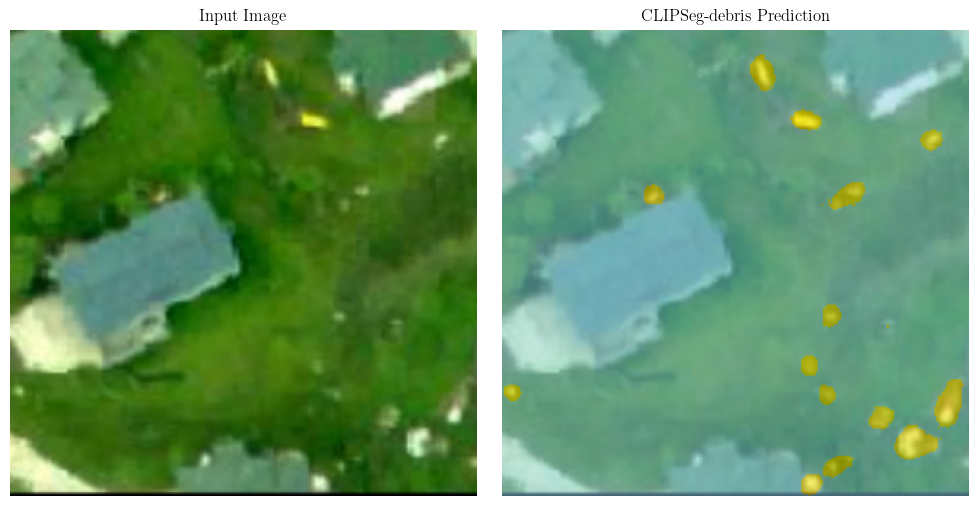

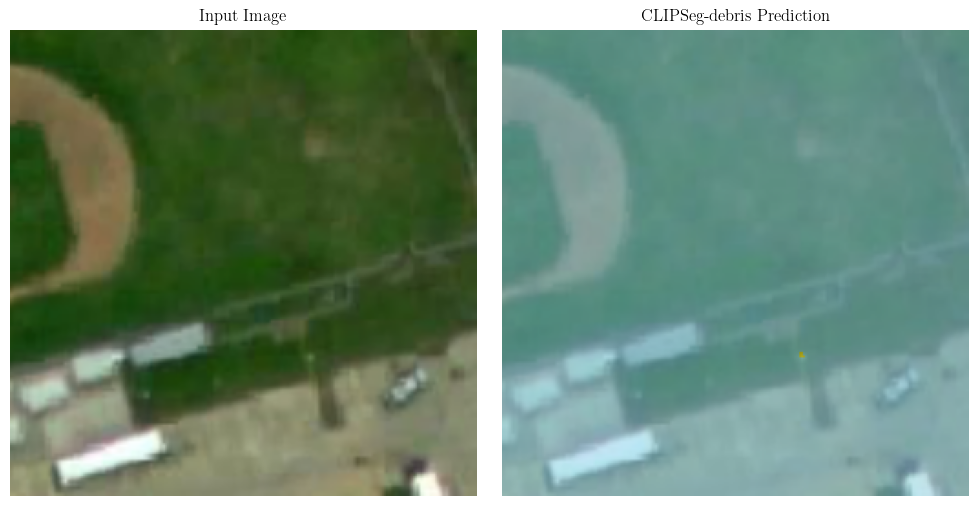

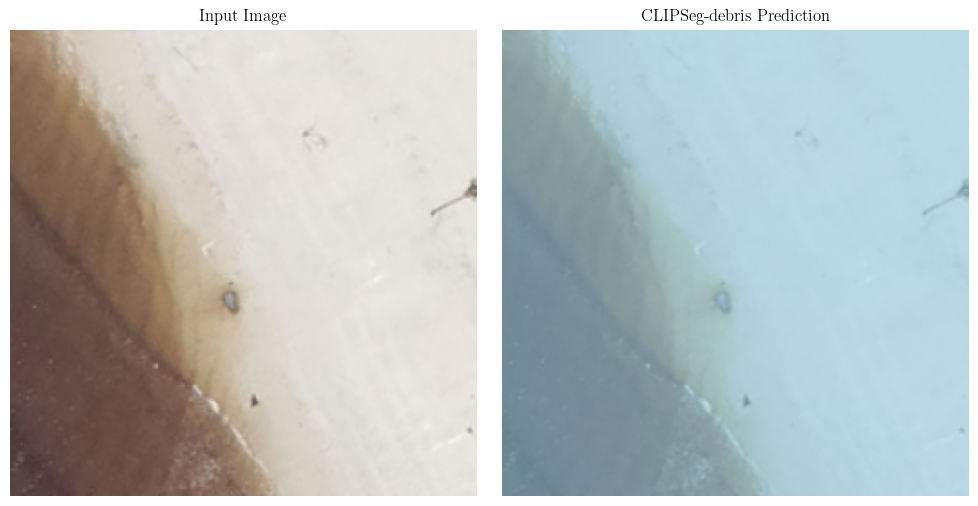

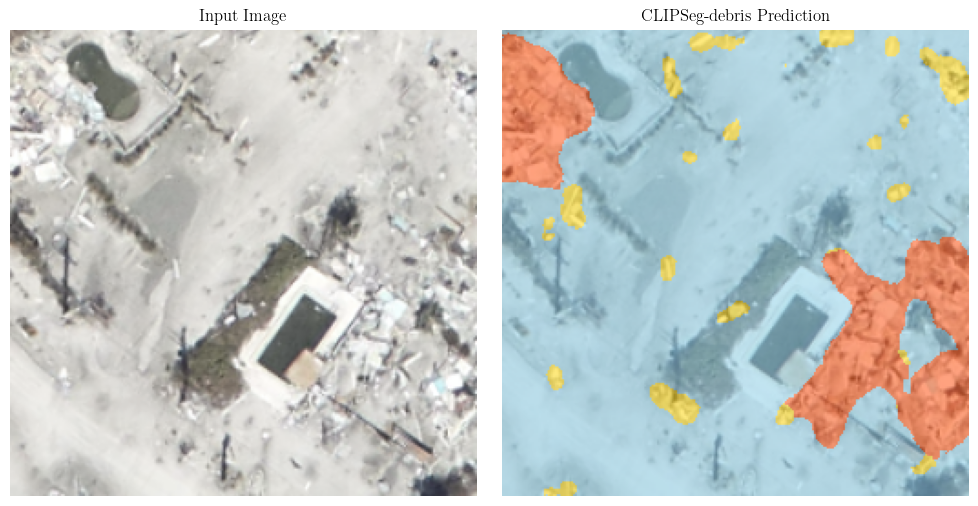

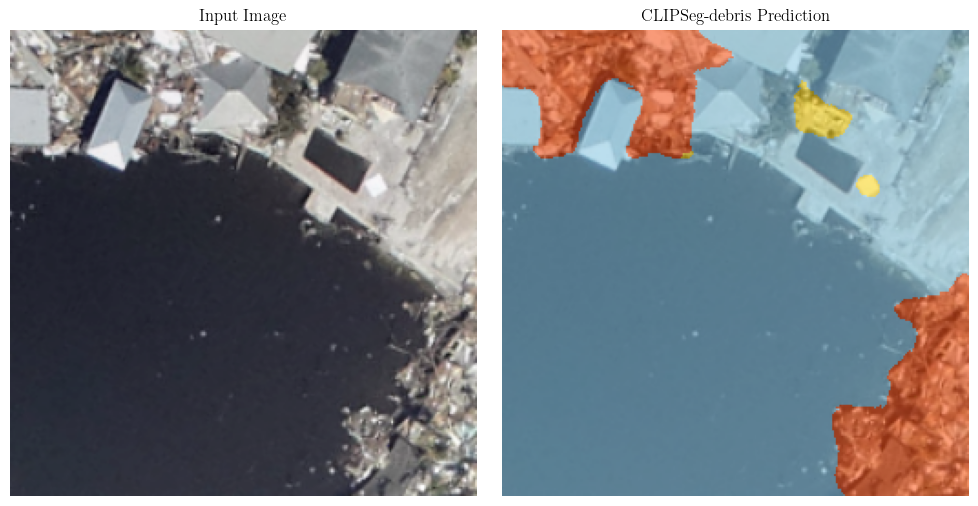

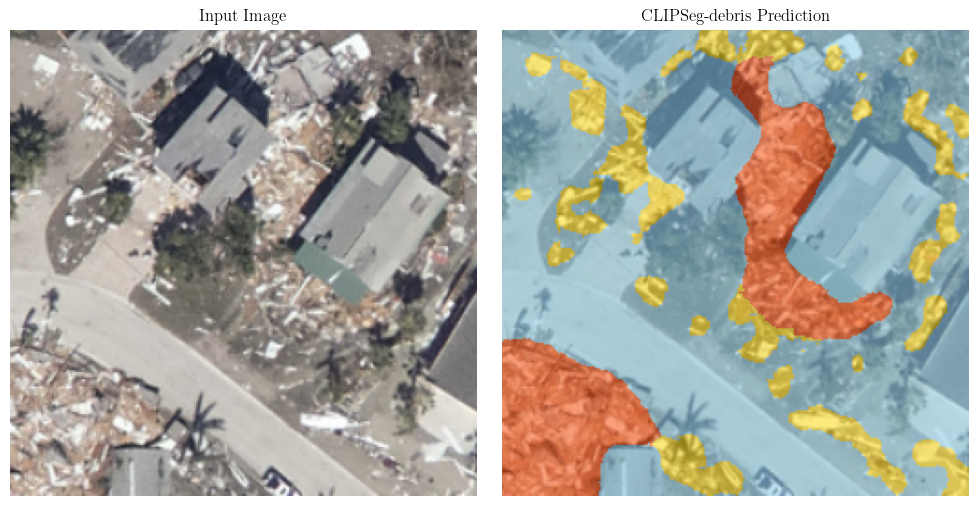

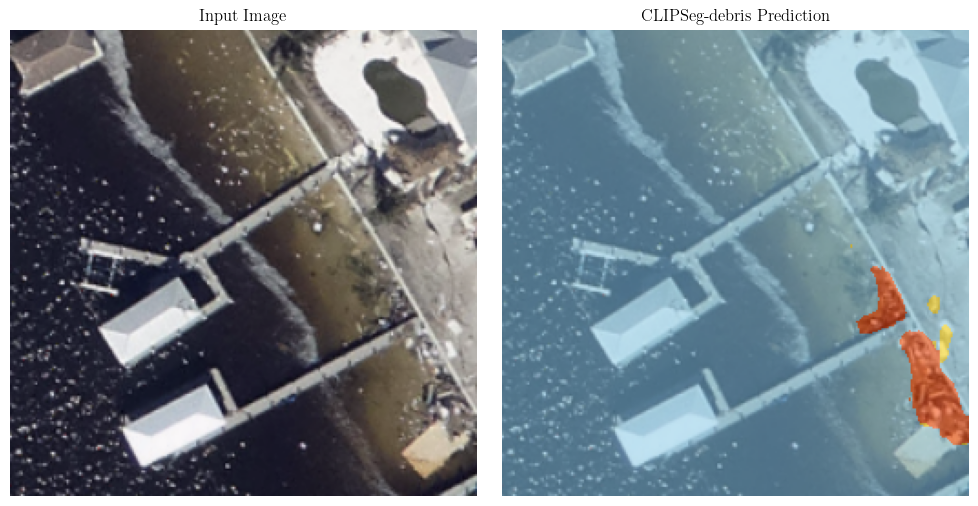

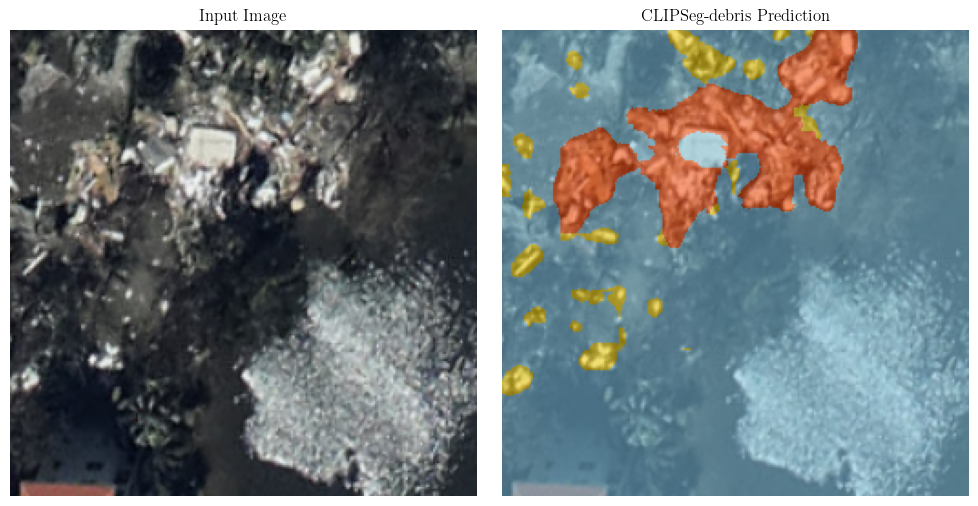

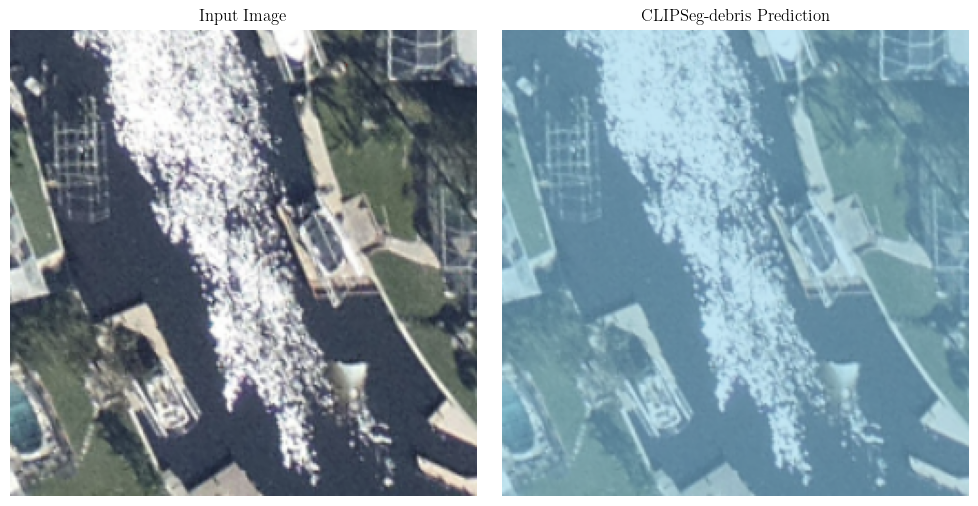

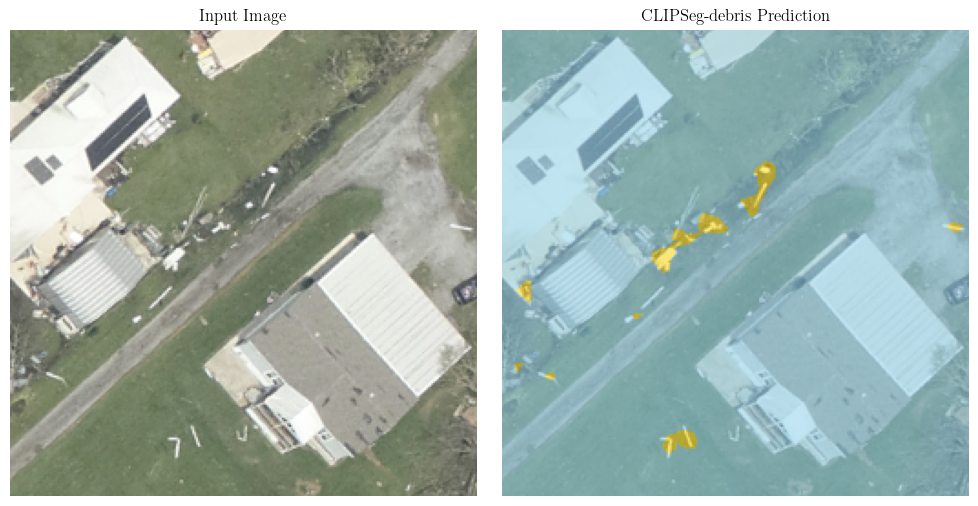

In [44]:
import cv2
import matplotlib.pyplot as plt

demo_dir = EXPERIMENTS_ROOT / prediction_dir
input_images_dir = demo_dir / "original"
prediction_images_dir = demo_dir / "predictions"

print("Input images dir:", input_images_dir)
print("Prediction images dir:", prediction_images_dir)

if not input_images_dir.exists() or not list(input_images_dir.iterdir()):
    print("⚠️ No input images found in:", input_images_dir)
elif not prediction_images_dir.exists() or not list(prediction_images_dir.iterdir()):
    print("⚠️ No prediction images found in:", prediction_images_dir)
else:
    input_files = sorted(f for f in input_images_dir.iterdir() if f.is_file())
    pred_files = sorted(f for f in prediction_images_dir.iterdir() if f.is_file())

    for inp, pred in zip(input_files, pred_files):
        input_img = cv2.imread(str(inp))
        prediction_img = cv2.imread(str(pred))

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Input Image")
        axes[0].axis("off")

        axes[1].imshow(cv2.cvtColor(prediction_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title("CLIPSeg-debris Prediction")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()